# **Aprendizaje por refuerzos** - FrozenLake y LunarLander (Gymnasium)

## Tarea: Implementar Agentes Q-Learning y DQN

### Objetivos:
1. Implementar el algoritmo Q-Learning
2. Implementar el algoritmo DQN
3. Entrenar y evaluar ambos agentes
4. Comparar el rendimiento de ambos enfoques


In [4]:
# Instalar paquetes requeridos
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

%pip install swig matplotlib gymnasium torch pygame


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Importar las bibliotecas
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pygame
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import deque, namedtuple
import random


C:\Users\Pc\AppData\Roaming\Python\Python313\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


La siguiente celda permite ejecutar un juego de Frozen Lake *determinista* para jugar con el teclado.

Utilize las teclas de dirección (flechas) o asdw para comandar al agente.


In [5]:
def jugar_frozen_lake(env):
    env.reset()
    
    print("Controles:")
    print("W - Arriba")
    print("S - Abajo") 
    print("A - Izquierda")
    print("D - Derecha")
    print("Q - Salir")
    print("Presione cualquier tecla para empezar...")
    
    pygame.init()
    pygame.display.set_caption("FrozenLake - Juego Interactivo")
    
    clock = pygame.time.Clock()
    ejecutando = True
    
    while ejecutando:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                ejecutando = False
            elif event.type == pygame.KEYDOWN:
                if event.key == pygame.K_q or event.key == pygame.K_ESCAPE:
                    ejecutando = False
                elif event.key == pygame.K_w or event.key == pygame.K_UP:
                    accion = 3  # Arriba
                elif event.key == pygame.K_s or event.key == pygame.K_DOWN:
                    accion = 1  # Abajo
                elif event.key == pygame.K_a or event.key == pygame.K_LEFT:
                    accion = 0  # Izquierda
                elif event.key == pygame.K_d or event.key == pygame.K_RIGHT:
                    accion = 2  # Derecha
                else:
                    continue
                
                observacion, recompensa, terminado, truncado, info = env.step(accion)
                print(f"Acción: {accion}, Recompensa: {recompensa}, Terminado: {terminado}")
                
                if terminado or truncado:
                    print(f"¡Episodio terminado! Recompensa final: {recompensa}")
                    pygame.time.wait(500)
                    env.reset()
        
        clock.tick(60)
    
    pygame.quit()
    env.close()

env = gym.make('FrozenLake-v1', render_mode='human', is_slippery=False)
# Descomente la línea de abajo para jugar interactivamente
# jugar_frozen_lake(env)


La siguiente celda permite jugar al juego no determinista.

In [ ]:
env = gym.make('FrozenLake-v1', render_mode='human', is_slippery=True)
# Descomente la línea de abajo para jugar interactivamente
jugar_frozen_lake(env)

La siguiente clase define la interfaz de los agentes que utilizaremos para jugar al Frozen Lake.


In [6]:
from abc import ABC, abstractmethod

class Agente(ABC):
    
    @abstractmethod
    def elegir_accion(self, estado):
        """Elige una acción dada una observación."""
        pass
    
    @abstractmethod
    def aprender(self, estado, accion, recompensa, siguiente_estado, terminado):
        """Aprende de la experiencia."""
        pass

class AgenteAleatorio(Agente):
    """Agente aleatorio que elige acciones al azar."""
    
    def __init__(self, espacio_acciones):
        # Se guarda el espacio de acciones para poder elegir acciones al azar
        self.espacio_acciones = espacio_acciones
    
    def elegir_accion(self, estado):
        return self.espacio_acciones.sample()
    
    def aprender(self, estado, accion, recompensa, siguiente_estado, terminado):
        pass  # El agente aleatorio no aprende

# Probar el AgenteAleatorio
env = gym.make('FrozenLake-v1')
agente_aleatorio = AgenteAleatorio(env.action_space)
estado, _ = env.reset()
accion = agente_aleatorio.elegir_accion(estado)
print(f"✓ AgenteAleatorio creado y probado. Acción: {accion}")
env.close()


✓ AgenteAleatorio creado y probado. Acción: 3


La siguiente celda define una función para evaluar el desempeño de un agente dado.

In [7]:
# Función de Evaluación de Agentes
def evaluar_agente(agente, env, num_episodios=1000):
    """
    Evalúa el rendimiento de un agente a lo largo de múltiples episodios.
    
    Args:
        agente: El agente a evaluar
        env: El entorno
        num_episodios: Número de episodios a ejecutar
    
    Returns:
        dict: Resultados de la evaluación
    """
    recompensas_totales = []
    victorias = 0
    
    for episodio in range(num_episodios):
        estado, _ = env.reset()
        recompensa_total = 0
        
        while True:
            accion = agente.elegir_accion(estado)
            estado, recompensa, terminado, truncado, _ = env.step(accion)
            recompensa_total += recompensa
            
            if terminado or truncado:
                break
        
        recompensas_totales.append(recompensa_total)
        if recompensa_total > 0:
            victorias += 1
    
    return {
        'recompensas_totales': recompensas_totales,
        'victorias': victorias,
        'tasa_victorias': victorias / num_episodios,
        'recompensa_promedio': np.mean(recompensas_totales),
        'desv_estandar': np.std(recompensas_totales)
    }

def imprimir_resultados_evaluacion(resultados, nombre_agente):
    """Imprime los resultados de evaluación de forma formateada."""
    print(f"\n{nombre_agente} - Resultados de Evaluación:")
    print(f"Tasa de Victorias: {resultados['tasa_victorias']:.1%}")
    print(f"Recompensa Promedio: {resultados['recompensa_promedio']:.3f}")
    print(f"Desviación Estándar: {resultados['desv_estandar']:.3f}")
    print(f"Total de Victorias: {resultados['victorias']}")

# Probar función de evaluación
env = gym.make('FrozenLake-v1')
agente_aleatorio = AgenteAleatorio(env.action_space)
resultados = evaluar_agente(agente_aleatorio, env, num_episodios=100)
imprimir_resultados_evaluacion(resultados, "Agente Aleatorio")
env.close()



Agente Aleatorio - Resultados de Evaluación:
Tasa de Victorias: 0.0%
Recompensa Promedio: 0.000
Desviación Estándar: 0.000
Total de Victorias: 0


La siguiente celda define una función para entrenar un agente.

In [8]:
# Función de Entrenamiento de Agentes
def entrenar_agente(agente, env, num_episodios=1000, max_pasos=100, verbose=True):
    """
    Entrena un agente en el entorno.
    
    Args:
        agente: El agente a entrenar
        env: El entorno
        num_episodios: Número de episodios de entrenamiento
        max_pasos: Máximo de pasos por episodio
        verbose: Si imprimir el progreso
    
    Returns:
        list: Recompensas de episodios
    """
    recompensas_episodios = []
    longitudes_episodios = []
    num_episodios_10 = int(num_episodios / 10)
    
    for episodio in range(num_episodios):
        estado, _ = env.reset()
        recompensa_total = 0
        pasos = 0
        
        for paso in range(max_pasos):
            accion = agente.elegir_accion(estado)
            siguiente_estado, recompensa, terminado, truncado, _ = env.step(accion)
            
            agente.aprender(estado, accion, recompensa, siguiente_estado, terminado or truncado)
            
            estado = siguiente_estado
            recompensa_total += recompensa
            pasos += 1
            
            if terminado or truncado:
                break
        
        recompensas_episodios.append(recompensa_total)
        longitudes_episodios.append(pasos)
        
        # Decaer epsilon si el agente tiene ese método
        if hasattr(agente, 'decaer_epsilon'):
            agente.decaer_epsilon()
        
        if verbose and (episodio + 1) % num_episodios_10 == 0:
            recompensa_promedio = np.mean(recompensas_episodios[-num_episodios_10:])
            longitud_promedio = np.mean(longitudes_episodios[-num_episodios_10:])
            epsilon_actual = getattr(agente, 'epsilon', 'N/A')
            print(f"Episodio {episodio + 1}: Recompensa Promedio = {recompensa_promedio:.3f}, Longitud Promedio = {longitud_promedio:.1f}, Epsilon = {epsilon_actual:.3f}")
    
    return recompensas_episodios, longitudes_episodios

print("✓ Funciones de entrenamiento definidas")


✓ Funciones de entrenamiento definidas


La siguiente celda define el agente de Q-Learning a implementar.

In [ ]:
# TODO: Implementar Agente Q-Learning
class AgenteQLearning(Agente):
    """Agente que usa el algoritmo Q-Learning."""
    
    def __init__(self, observation_space_n, action_space_n, alpha_offset, alpha_min, gamma, epsilon, epsilon_decay):
        """
        Inicializa el agente Q-Learning.

        Args:
            observation_space_n (int): Número de estados posibles.
            action_space_n (int): Número de acciones posibles.
            alpha_offset (float): Offset para el cálculo de alpha dinámico.
            alpha_min (float): Valor mínimo de alpha.
            gamma (float): Factor de descuento.
            epsilon (float): Probabilidad inicial de exploración (epsilon-greedy).
            epsilon_decay (float): Cantidad fija a disminuir epsilon por episodio.
        """
        self.qtable = np.zeros((observation_space_n, action_space_n)) 
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.action_space_n = action_space_n # Guardamos el número de acciones
        
        # Para α dinámico
        self.visitas = np.zeros_like(self.qtable, dtype=np.int64)
        self.alpha_offset = alpha_offset
        self.alpha_min = alpha_min
    
    def elegir_accion(self, estado):
        """Elige una acción usando política epsilon-greedy."""
        # Decaimiento de epsilon se maneja en el bucle de entrenamiento,
        # pero aquí usamos el valor actual de epsilon.
        if random.uniform(0, 1) < self.epsilon:
            # Exploración: elige una acción aleatoria
            return random.randint(0, self.action_space_n - 1)
        else:
            # Explotación: elige la acción con el valor Q más alto para el estado actual
            return np.argmax(self.qtable[estado, :])
    
    def aprender(self, estado, accion, recompensa, siguiente_estado, terminado):
        """Actualiza la tabla Q usando alpha dinámico basado en visitas."""
        # Incrementar contador de visitas
        self.visitas[estado, accion] += 1
        
        # Calcular α dinámico: α(s,a) = max(α_min, 1/(offset + visitas))
        alpha_sa = max(self.alpha_min, 1.0 / (self.alpha_offset + self.visitas[estado, accion]))
        
        # Calcular target de TD
        if terminado:
            td_target = recompensa
        else:
            td_target = recompensa + self.gamma * np.max(self.qtable[siguiente_estado, :])
        
        # Actualizar Q-table con fórmula optimizada: Q = (1-α)*Q_old + α*target
        q_old = self.qtable[estado, accion]
        self.qtable[estado, accion] = (1.0 - alpha_sa) * q_old + alpha_sa * td_target
    
    def decaer_epsilon(self):
        """Reduce el valor de epsilon para disminuir la exploración con el tiempo."""
        self.epsilon = max(0.01, self.epsilon - self.epsilon_decay) # Aseguramos que epsilon no baje de 0.01 para algo de exploración
    
    def get_alpha_promedio(self):
        """Obtiene el valor promedio actual de alpha para análisis."""
        alphas = []
        for s in range(self.qtable.shape[0]):
            for a in range(self.qtable.shape[1]):
                if self.visitas[s, a] > 0:
                    alpha_sa = max(self.alpha_min, 1.0 / (self.alpha_offset + self.visitas[s, a]))
                    alphas.append(alpha_sa)
        return np.mean(alphas) if alphas else self.alpha_min


Aqui deberán incluir código para entrenar y evaluar el agente de Q-Learning implementado.

In [33]:
# Entrenamiento avanzado con checkpoint, alpha-decay y evaluación greedy

import copy
import pandas as pd
import time

def evaluar_greedy(agente, env, num_episodios=1000, max_pasos=250):
    eps_backup = agente.epsilon
    agente.epsilon = 0.0  # política puramente codiciosa
    resultados = evaluar_agente(agente, env, num_episodios=num_episodios)
    agente.epsilon = eps_backup
    return resultados



Estrategia α(s,a) = max(α_min, 1/(offset + visitas))

🚀 Probando configuraciones optimizadas...

🧪 Configuración 1: Ultra_A2: γ=0.998, exploración extendida
   γ=0.998, α_offset=15, α_min=0.04
Entrenando 100000 episodios en 10 bloques de 10000
α dinámico: α(s,a) = max(0.04, 1/(15 + visitas))
Bloque 1/10 | tasa_greedy=52.7% | ε=0.8342 | α_prom=0.0414
Bloque 1/10 | tasa_greedy=52.7% | ε=0.8342 | α_prom=0.0414
Bloque 2/10 | tasa_greedy=49.1% | ε=0.6683 | α_prom=0.0410
Bloque 2/10 | tasa_greedy=49.1% | ε=0.6683 | α_prom=0.0410
Bloque 3/10 | tasa_greedy=53.8% | ε=0.5025 | α_prom=0.0404
Bloque 3/10 | tasa_greedy=53.8% | ε=0.5025 | α_prom=0.0404
Bloque 4/10 | tasa_greedy=52.7% | ε=0.3367 | α_prom=0.0402
Bloque 4/10 | tasa_greedy=52.7% | ε=0.3367 | α_prom=0.0402
Bloque 5/10 | tasa_greedy=35.5% | ε=0.1708 | α_prom=0.0400
Bloque 5/10 | tasa_greedy=35.5% | ε=0.1708 | α_prom=0.0400
Bloque 6/10 | tasa_greedy=17.8% | ε=0.0100 | α_prom=0.0400
Bloque 6/10 | tasa_greedy=17.8% | ε=0.0100 | α_prom=0.0400

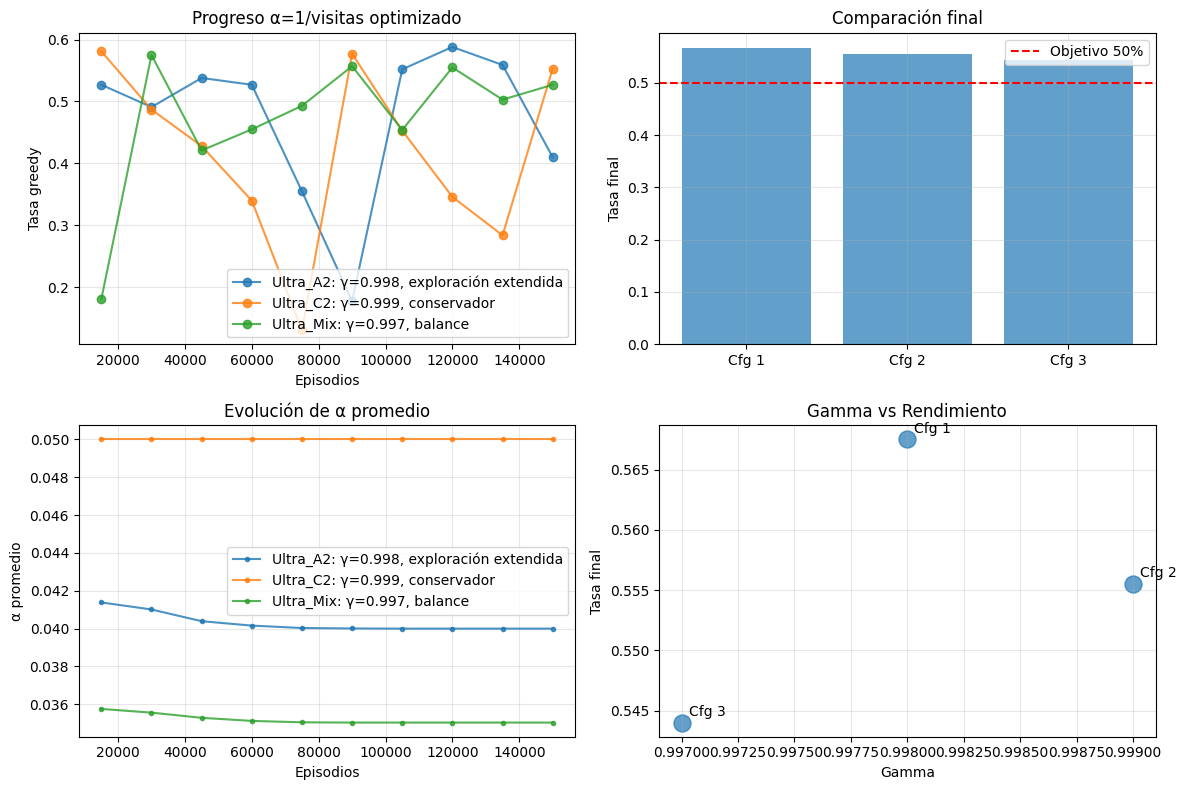


📋 TABLA DETALLADA:
                                  nombre  tasa_final  gamma  alpha_offset  alpha_min  tiempo_s
Ultra_A2: γ=0.998, exploración extendida      0.5675  0.998            15      0.040   99.7295
          Ultra_C2: γ=0.999, conservador      0.5555  0.999            25      0.050   97.1087
             Ultra_Mix: γ=0.997, balance      0.5440  0.997            20      0.035   96.2043


In [ ]:
print("Estrategia α(s,a) = max(α_min, 1/(offset + visitas))")
print("="*60)

# Usamos otra version de alpha dinamico, ya que α=1/n decae muy rápido y "congela" valores Q.

def entrenar_alpha_visitas_optimizado(cfg, episodios_total=150000, tam_bloque=15000, 
                                      max_pasos=300, eval_intermedia=1000, epsilon_min=0.005,
                                      alpha_offset=25, alpha_min=0.03):
    """
    Versión de alpha modificada con:
    1. α(s,a) = max(α_min, 1/(offset + visitas)) - para que no caiga muy rápido
    2. ε_min más bajo (0.005) - más exploración tardía
    3. Más episodios y pasos por episodio
    """
    env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
    agente = AgenteQLearning(
        observation_space_n=env.observation_space.n,
        action_space_n=env.action_space.n,
        alpha_offset=alpha_offset,
        alpha_min=alpha_min,
        gamma=cfg['gamma'],
        epsilon=1.0,
        epsilon_decay=cfg['epsilon_decay']
    )

    mejor_tasa = -1.0
    mejor_q = None
    progreso = []

    bloques = max(1, episodios_total // tam_bloque)
    print(f"Entrenando {episodios_total} episodios en {bloques} bloques de {tam_bloque}")
    print(f"α dinámico: α(s,a) = max({alpha_min}, 1/({alpha_offset} + visitas))")
    
    for b in range(bloques):
        for ep in range(tam_bloque):
            estado, _ = env.reset()
            for paso in range(max_pasos):
                accion = agente.elegir_accion(estado)
                siguiente_estado, recompensa, terminado, truncado, _info = env.step(accion)

                # Usar método de aprendizaje con alpha dinamico
                agente.aprender(estado, accion, recompensa, siguiente_estado, terminado or truncado)

                estado = siguiente_estado
                if terminado or truncado:
                    break

            # Decaimiento más lento de epsilon
            agente.epsilon = max(epsilon_min, agente.epsilon - agente.epsilon_decay)

        # Evaluación y checkpoint
        res_mid = evaluar_greedy(agente, env, num_episodios=eval_intermedia, max_pasos=max_pasos)
        tasa_mid = res_mid['tasa_victorias']
        
        # Calcular α promedio actual
        alpha_promedio = agente.get_alpha_promedio()
        
        progreso.append({
            'bloque': b + 1, 'tasa': tasa_mid, 'epsilon': agente.epsilon, 
            'alpha_promedio': alpha_promedio, 'visitas_total': np.sum(agente.visitas)
        })
        print(f"Bloque {b+1}/{bloques} | tasa_greedy={tasa_mid:.1%} | ε={agente.epsilon:.4f} | α_prom={alpha_promedio:.4f}")

        if tasa_mid > mejor_tasa:
            mejor_tasa = tasa_mid
            mejor_q = copy.deepcopy(agente.qtable)

    if mejor_q is not None:
        agente.qtable = mejor_q

    res_final = evaluar_greedy(agente, env, num_episodios=2000, max_pasos=max_pasos)
    env.close()
    return agente, res_final, pd.DataFrame(progreso)


# Configuraciones optimizadas para α=1/visitas
configs_optimizadas = [
    {
        'nombre': 'Ultra_A2: γ=0.998, exploración extendida',
        'alpha': 0.1, 'gamma': 0.998,
        'epsilon_decay': (1.0 - 0.005) / (100000 * 0.6),  # 60% exploración
        'alpha_offset': 15, 'alpha_min': 0.04
    },
    {
        'nombre': 'Ultra_C2: γ=0.999, conservador',
        'alpha': 0.1, 'gamma': 0.999,
        'epsilon_decay': (1.0 - 0.003) / (100000 * 0.7),  # 70% exploración
        'alpha_offset': 25, 'alpha_min': 0.05
    },
    {
        'nombre': 'Ultra_Mix: γ=0.997, balance',
        'alpha': 0.1, 'gamma': 0.997,
        'epsilon_decay': (1.0 - 0.004) / (100000 * 0.65),  # 65% exploración
        'alpha_offset': 20, 'alpha_min': 0.035
    }
]

print("\n🚀 Probando configuraciones optimizadas...")
resultados_optimizacion = []

for i, cfg in enumerate(configs_optimizadas):
    print(f"\n🧪 Configuración {i+1}: {cfg['nombre']}")
    print(f"   γ={cfg['gamma']}, α_offset={cfg['alpha_offset']}, α_min={cfg['alpha_min']}")
    
    # Crear configuración compatible (sin alpha fijo)
    cfg_compatible = {
        'gamma': cfg['gamma'], 
        'epsilon_decay': cfg['epsilon_decay']
    }
    
    t0 = time.time()
    agent_opt, res_opt, prog_opt = entrenar_alpha_visitas_optimizado(
        cfg_compatible,
        episodios_total=100000,
        tam_bloque=10000,
        max_pasos=350,
        eval_intermedia=1000,
        epsilon_min=0.01,
        alpha_offset=cfg['alpha_offset'],
        alpha_min=cfg['alpha_min']
    )
    tiempo_opt = time.time() - t0
    
    # Política final
    acciones_mapa = {0: '←', 1: '↓', 2: '→', 3: '↑'}
    policy_opt = np.array([acciones_mapa[int(np.argmax(agent_opt.qtable[s, :]))] 
                          for s in range(agent_opt.qtable.shape[0])]).reshape(4, 4)
    
    resultado_opt = {
        'nombre': cfg['nombre'],
        'tasa_final': res_opt['tasa_victorias'],
        'recompensa': res_opt['recompensa_promedio'],
        'desv_std': res_opt['desv_estandar'],
        'tiempo_s': tiempo_opt,
        'gamma': cfg['gamma'],
        'alpha_offset': cfg['alpha_offset'],
        'alpha_min': cfg['alpha_min'],
        'politica': policy_opt,
        'progreso': prog_opt
    }
    
    resultados_optimizacion.append(resultado_opt)
    
    print(f"   ✅ Resultado: {res_opt['tasa_victorias']:.1%}")
    print(f"   ⏱️  Tiempo: {tiempo_opt:.1f}s")
    print(f"   🧭 Política final:\n{policy_opt}")

# Análisis de resultados
print("\n" + "="*60)
print("📊 RESULTADOS ")
print("="*60)

df_opt = pd.DataFrame(resultados_optimizacion)
df_opt_sorted = df_opt.sort_values('tasa_final', ascending=False)

mejor_opt = df_opt_sorted.iloc[0]
print(f"\n🏆 MEJOR RESULTADO:")
print(f"   {mejor_opt['nombre']}: {mejor_opt['tasa_final']:.1%}")
print(f"   γ={mejor_opt['gamma']}, α_offset={mejor_opt['alpha_offset']}, α_min={mejor_opt['alpha_min']}")
print(f"   Recompensa: {mejor_opt['recompensa']:.3f} ± {mejor_opt['desv_std']:.3f}")


# Gráfico de progreso
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
for i, res in enumerate(resultados_optimizacion):
    prog = res['progreso']
    plt.plot(prog['bloque'] * 15000, prog['tasa'], 
             marker='o', label=res['nombre'], alpha=0.8)
plt.xlabel('Episodios')
plt.ylabel('Tasa greedy')
plt.title('Progreso α=1/visitas optimizado')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.bar(range(len(df_opt)), df_opt['tasa_final'], alpha=0.7)
plt.axhline(y=0.5, color='red', linestyle='--', label='Objetivo 50%')
plt.xticks(range(len(df_opt)), [f"Cfg {i+1}" for i in range(len(df_opt))])
plt.ylabel('Tasa final')
plt.title('Comparación final')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
for i, res in enumerate(resultados_optimizacion):
    prog = res['progreso']
    plt.plot(prog['bloque'] * 15000, prog['alpha_promedio'], 
             marker='.', label=res['nombre'], alpha=0.8)
plt.xlabel('Episodios')
plt.ylabel('α promedio')
plt.title('Evolución de α promedio')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.scatter(df_opt['gamma'], df_opt['tasa_final'], s=150, alpha=0.7)
for i, row in df_opt.iterrows():
    plt.annotate(f"Cfg {i+1}", (row['gamma'], row['tasa_final']), 
                xytext=(5, 5), textcoords='offset points')
plt.xlabel('Gamma')
plt.ylabel('Tasa final')
plt.title('Gamma vs Rendimiento')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📋 TABLA DETALLADA:")
tabla_opt = df_opt_sorted[['nombre', 'tasa_final', 'gamma', 'alpha_offset', 'alpha_min', 'tiempo_s']].round(4)
print(tabla_opt.to_string(index=False))